# 10 · Transformers and Self-Attention

**A note on scope.** Fetching a real pretrained tokenizer and transformer (e.g. BERT)
would add a large download and a new dependency for a few lines of illustration.
Instead this chapter implements **scaled dot-product attention and multi-head
attention from scratch in NumPy** on small, explicit, worked examples — the actual
mechanism, not a library call around it — which trains (there's nothing to train) and
runs instantly.

**Objectives:** implement scaled dot-product attention, see it resolve a pronoun
reference in a toy sentence, extend it to multi-head attention, and add a causal mask
for autoregressive generation.

## 1. Tokens as vectors, and the idea of attention

A transformer reads a sentence as a list of **tokens** (words or pieces of words). Each token is represented by a vector of numbers, its **embedding**. The $n$ token vectors of a sentence are stacked as the rows of a matrix

$$X \in \mathbb R^{n \times d_{\text{model}}},$$

where $n$ is the number of tokens and $d_{\text{model}}$ the length of each vector. Row $i$, written $\mathbf x_i$, stands for token $i$.

An embedding describes a word out of context. Meaning, however, depends on context: in *"The animal didn't cross because it was tired"*, the vector for "it" should end up carrying information about "animal". **Self-attention** is the operation that does this. Every token looks at every token of the sentence (itself included), decides how relevant each one is, and replaces its own vector by a weighted average of what it found, the relevant tokens weighing most.

Think of a library. You arrive with a **query** (what you are looking for). Every book has a **key** (the label on its spine) and a **value** (its content). You compare your query with every key and read mostly the books whose keys match. Attention does the same, except that it reads every book a little, in proportion to how well it matches.

## 2. Scaled dot-product attention, step by step

**Step 1: queries, keys, values.** Each token plays three roles, obtained from its embedding by three learned matrices:

$$Q = X W_Q, \qquad K = X W_K, \qquad V = X W_V .$$

$W_Q$ and $W_K$ have shape $d_{\text{model}} \times d_k$ and $W_V$ has shape $d_{\text{model}} \times d_v$, so $Q$ and $K$ are $n \times d_k$ and $V$ is $n \times d_v$. Row $i$ of $Q$, written $\mathbf q_i$, is what token $i$ is looking for; row $j$ of $K$, $\mathbf k_j$, is what token $j$ can be found by; row $j$ of $V$, $\mathbf v_j$, is what token $j$ hands over once found.

**Step 2: scores.** The match between a query and a key is their dot product:

$$s_{ij} = \mathbf q_i \cdot \mathbf k_j = \sum_{m=1}^{d_k} q_{im}\, k_{jm}.$$

It is large and positive when the two vectors point the same way, zero when they are perpendicular, negative when they point in opposite directions. All $n^2$ scores form the matrix $S = QK^\top$ ($n \times n$); row $i$ holds how token $i$ rates every token.

**Step 3: scaling.** Every score is divided by $\sqrt{d_k}$. The reason is statistical. Suppose the components $q_m$ and $k_m$ of a query and a key are independent random numbers with mean 0 and variance 1. Each product $q_m k_m$ then has mean $\mathbb E[q_m]\,\mathbb E[k_m] = 0$, and variance

$$\mathrm{Var}(q_m k_m) = \mathbb E[q_m^2 k_m^2] - 0^2 = \mathbb E[q_m^2]\,\mathbb E[k_m^2] = 1 \cdot 1 = 1.$$

The dot product is a sum of $d_k$ such independent terms, and variances of independent terms add:

$$\mathrm{Var}(\mathbf q \cdot \mathbf k) = \sum_{m=1}^{d_k} \mathrm{Var}(q_m k_m) = d_k .$$

So the typical size of a score (its standard deviation) grows like $\sqrt{d_k}$: with $d_k = 64$, scores of $\pm 8$ are routine. Dividing by $\sqrt{d_k}$ brings the variance back to $d_k / d_k = 1$, whatever the dimension. Step 4 shows why large scores would hurt.

**Step 4: softmax.** Write $u_{ij} = s_{ij}/\sqrt{d_k}$ for the scaled scores. Each row is turned into weights by the **softmax**:

$$a_{ij} = \frac{e^{u_{ij}}}{\sum_{l=1}^{n} e^{u_{il}}}.$$

Its properties can be read off the formula:

- every $a_{ij}$ is positive, since an exponential is positive;
- each row sums to 1, since the denominator is the sum of the numerators; row $i$ is a probability distribution over the tokens that token $i$ attends to;
- a higher score always gets a higher weight;
- adding the same constant $c$ to a whole row changes nothing, since $e^{c}$ multiplies numerator and denominator alike (the code subtracts the row maximum before exponentiating, which avoids overflow);
- it is sensitive to spread: scores $(0, 1)$ give weights $(0.27, 0.73)$, scores $(0, 8)$ give $(0.0003, 0.9997)$.

The last point is the one the scaling addresses. The derivative of the softmax is $\partial a_{ij}/\partial u_{il} = a_{ij}(\delta_{jl} - a_{il})$, with $\delta_{jl} = 1$ if $j = l$ and 0 otherwise. When one weight is near 1 and the others near 0, every such product is near 0, and gradient-based learning stalls.

**Step 5: weighted average of values.** The output for token $i$ is

$$\mathbf o_i = \sum_{j=1}^{n} a_{ij}\, \mathbf v_j .$$

The weights are positive and sum to 1, so $\mathbf o_i$ is an average of the value vectors, pulled toward the tokens that token $i$ found most relevant.

**All together.** Steps 2 to 5, for all tokens at once, are one line of matrix algebra:

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V ,$$

with the softmax applied to each row. The softmax produces the weight matrix $A$ ($n \times n$, entries $a_{ij}$), and multiplying by $V$ gives one output row per token ($n \times d_v$).

## 3. A worked example by hand

Three tokens with 2-D embeddings. As in the code's first example, the embeddings are used directly as queries, keys and values ($Q = K = V = X$, so $d_k = 2$):

$$X = \begin{pmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 1 \end{pmatrix}, \qquad \mathbf x_1 = (1, 0),\quad \mathbf x_2 = (0, 1),\quad \mathbf x_3 = (1, 1).$$

**Scores.** $S = QK^\top = XX^\top$. For instance $s_{13} = \mathbf x_1 \cdot \mathbf x_3 = 1 \cdot 1 + 0 \cdot 1 = 1$ and $s_{33} = 1 + 1 = 2$. Then divide by $\sqrt 2 \approx 1.414$:

$$S = \begin{pmatrix} 1 & 0 & 1 \\ 0 & 1 & 1 \\ 1 & 1 & 2 \end{pmatrix}, \qquad \frac{S}{\sqrt 2} \approx \begin{pmatrix} 0.707 & 0 & 0.707 \\ 0 & 0.707 & 0.707 \\ 0.707 & 0.707 & 1.414 \end{pmatrix}.$$

**Softmax, row by row**, using $e^{0} = 1$, $e^{0.707} \approx 2.028$ and $e^{1.414} \approx 4.113$:

| query | exponentials | row sum | weights $a_{i1},\ a_{i2},\ a_{i3}$ |
|---|---|---|---|
| token 1 | 2.028, 1, 2.028 | 5.056 | 0.401, 0.198, 0.401 |
| token 2 | 1, 2.028, 2.028 | 5.056 | 0.198, 0.401, 0.401 |
| token 3 | 2.028, 2.028, 4.113 | 8.169 | 0.248, 0.248, 0.503 |

Each row sums to 1, up to rounding. Token 1 gives the least weight to token 2, whose vector is perpendicular to its own (score 0).

**Outputs.** $\mathbf o_1 = 0.401\,(1, 0) + 0.198\,(0, 1) + 0.401\,(1, 1) = (0.802,\ 0.599)$. In the same way $\mathbf o_2 = (0.599,\ 0.802)$ and $\mathbf o_3 = (0.752,\ 0.752)$. Token 1 started as $(1, 0)$ and now carries some of the second direction, borrowed from tokens 2 and 3: it has been mixed with its context.

**With a causal mask** (section 4), token 1 may only look at itself: weights $(1, 0, 0)$, output $(1, 0)$. Token 2 may look at tokens 1 and 2, with scaled scores $0$ and $0.707$: weights $1/3.028 \approx 0.330$ and $2.028/3.028 \approx 0.670$. Token 3 already sees everything before it, so its row is unchanged.

## 4. Multi-head attention, masks and word order

**Multi-head attention.** One weight matrix $A$ expresses one notion of relevance, but language has several at once: which noun a pronoun refers to, which verb goes with which subject, which words are neighbours. **Multi-head attention** runs $H$ attention computations, called heads, side by side. Head $h$ has its own projections $W_Q^{(h)}, W_K^{(h)}, W_V^{(h)}$, each of shape $d_{\text{model}} \times d_k$ with $d_k = d_{\text{model}}/H$:

$$\mathrm{head}_h = \mathrm{Attention}\big(XW_Q^{(h)},\ XW_K^{(h)},\ XW_V^{(h)}\big) \qquad (n \times d_k).$$

The $H$ outputs are placed side by side into an $n \times d_{\text{model}}$ matrix and mixed by one more learned matrix $W_O$ ($d_{\text{model}} \times d_{\text{model}}$):

$$\mathrm{MultiHead}(X) = \big[\,\mathrm{head}_1,\ \dots,\ \mathrm{head}_H\,\big]\, W_O .$$

Splitting $d_{\text{model}}$ among the heads keeps the cost close to that of one full-width head.

**Causal mask.** A model that generates text left to right predicts token $i+1$ from tokens 1 to $i$, so during training token $i$ must not attend to any later token. Before the softmax, every scaled score with $j > i$ is replaced by $-\infty$:

$$u_{ij} = \begin{cases} s_{ij}/\sqrt{d_k} & \text{if } j \le i, \\ -\infty & \text{if } j > i, \end{cases} \qquad \text{so} \qquad a_{ij} = 0 \ \text{ for } j > i,$$

because $e^{-\infty} = 0$. The remaining weights of each row still sum to 1, spread over the past and the present only, and $A$ becomes lower-triangular.

**Attention alone ignores word order.** Without a mask, nothing in the formula of section 2 knows where a token sits. Reorder the rows of $X$ with a permutation matrix $P$ (a matrix that shuffles rows, with $P^\top P = I$). Then $Q$, $K$ and $V$ are reordered the same way, the scores become $PSP^\top$ (rows and columns shuffled together), the row-wise softmax gives $PAP^\top$, and

$$\mathrm{Attention}(PX) = PAP^\top\, PV = PAV = P\,\mathrm{Attention}(X).$$

Reordering the input only reorders the output: attention is **permutation equivariant**. In "the dog bit the man" and "the man bit the dog", "dog" would get the same output vector. To make order visible, transformers add a **positional encoding** $\mathbf p_i$, a vector that depends only on the position $i$, to each embedding: $\mathbf x_i \leftarrow \mathbf x_i + \mathbf p_i$. The original transformer (Vaswani et al., 2017) uses sines and cosines of different frequencies, $p_{i,2m} = \sin\big(i/10000^{2m/d_{\text{model}}}\big)$ and $p_{i,2m+1} = \cos\big(i/10000^{2m/d_{\text{model}}}\big)$; many later models learn $\mathbf p_i$ instead. The examples below need no positions, because the link between "it" and "animal" is written into the embeddings directly.

**What the code does.** Section 5 writes the formula of section 2 as `scaled_dot_product_attention(Q, K, V, mask=None)`: `scores` is $QK^\top/\sqrt{d_k}$, masked entries become `-np.inf`, `softmax` normalises each row after subtracting its maximum, and the function returns `weights @ V` together with $A$ (`weights`). Section 6 builds `embeddings` for an 8-token sentence and uses them as `Q = K = V`, like the hand example. Section 7 implements `multi_head_attention` with `Wq`, `Wk`, `Wv`, `Wo` ($W_Q, W_K, W_V, W_O$): each is one $d_{\text{model}} \times d_{\text{model}}$ matrix whose columns are cut into `n_heads` blocks of `d_k` columns, which is the same as giving every head its own $d_{\text{model}} \times d_k$ projection. Section 8 builds the causal mask with `np.tril`; `True` marks the allowed positions $j \le i$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import mlutils
mlutils.set_style()
rng = np.random.default_rng(0)

## 5. Scaled dot-product attention in code

The function below is the formula of section 2, $\mathrm{softmax}(QK^\top/\sqrt{d_k})\,V$,
with the optional causal mask of section 4. It returns both the outputs and the weight
matrix, so the attention pattern can be plotted.

In [2]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)          # subtract max for numerical stability
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.swapaxes(-2, -1) / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask, scores, -np.inf)
    weights = softmax(scores, axis=-1)
    return weights @ V, weights

## 6. A worked example: resolving "it"

Take the classic ambiguous sentence *"The animal didn't cross because it was tired"*.
A reader instantly knows "it" means the animal, not the street or "because". To show
attention doing the same thing, we hand-build embeddings where "it"'s embedding is
partly built from "animal"'s (the token really does carry information pointing back
to what it refers to) and use the raw embeddings directly as $Q$, $K$ and $V$ — no
learned projection yet, so the attention pattern reflects nothing but embedding
similarity.

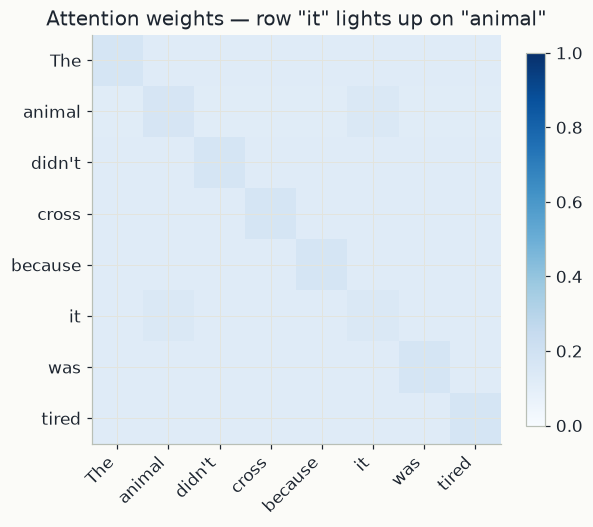

In [3]:
tokens = ["The", "animal", "didn't", "cross", "because", "it", "was", "tired"]
n = len(tokens)
embeddings = np.eye(n)                       # one-hot base: every token starts fully distinct

it_idx, animal_idx = tokens.index("it"), tokens.index("animal")
embeddings[it_idx] = 0.4 * embeddings[it_idx] + 0.6 * embeddings[animal_idx]   # "it" echoes "animal"

Q = K = V = embeddings
out, weights = scaled_dot_product_attention(Q, K, V)

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(weights, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(tokens)
ax.set_title('Attention weights — row "it" lights up on "animal"')
fig.colorbar(im, ax=ax, shrink=0.8)

In [4]:
it_weights = weights[it_idx]
for token, w in sorted(zip(tokens, it_weights), key=lambda p: -p[1])[:3]:
    print(f"{token!r}: {w:.3f}")

'animal': 0.147
'it': 0.142
'The': 0.119


The row for "it" puts most of its attention mass on "animal" (and on itself) — the
same coreference a reader resolves instantly. Nothing here was trained: this is pure
arithmetic once the embeddings encode the relationship, which is exactly the
computation a trained transformer performs once *its* embeddings (learned from data)
encode similar relationships.

## 7. Multi-head attention

Section 4 described multi-head attention: several attention computations in parallel,
each in a smaller subspace of the embedding with its own projections, concatenated and
mixed by $W_O$. The implementation below projects once with full
$d_{\text{model}} \times d_{\text{model}}$ matrices and then reshapes, so that each head
works on its own block of $d_k$ columns.

In [5]:
def multi_head_attention(X, n_heads, Wq, Wk, Wv, Wo):
    seq_len, d_model = X.shape
    d_k = d_model // n_heads
    Q, K, V = X @ Wq, X @ Wk, X @ Wv                       # (seq_len, d_model) each

    def split_heads(M):
        return M.reshape(seq_len, n_heads, d_k).transpose(1, 0, 2)   # (n_heads, seq_len, d_k)

    Qh, Kh, Vh = split_heads(Q), split_heads(K), split_heads(V)
    head_outputs, head_weights = [], []
    for h in range(n_heads):
        out_h, w_h = scaled_dot_product_attention(Qh[h], Kh[h], Vh[h])
        head_outputs.append(out_h)
        head_weights.append(w_h)
    concat = np.concatenate(head_outputs, axis=-1)          # back to (seq_len, d_model)
    return concat @ Wo, np.stack(head_weights)               # (n_heads, seq_len, seq_len)

multi-head output shape: (8, 8) (unchanged: seq_len x d_model)
per-head attention weights shape: (2, 8, 8) (n_heads, seq_len, seq_len)


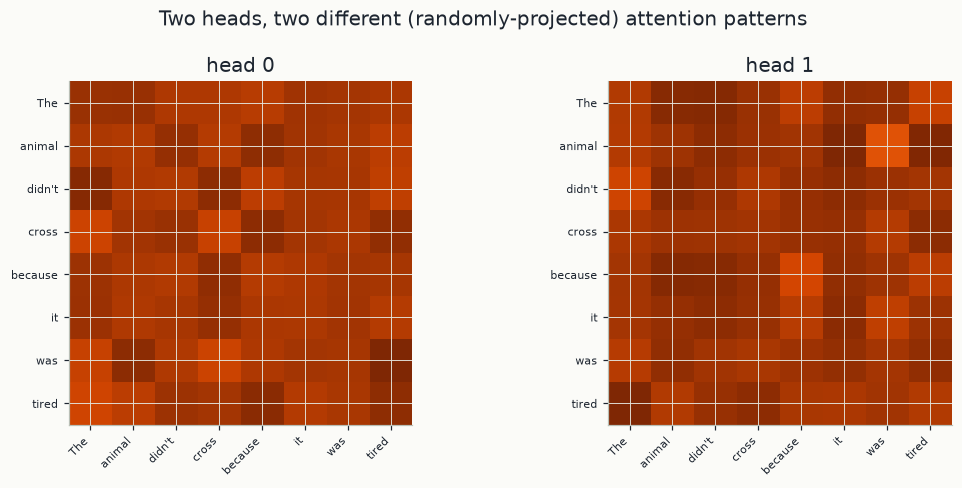

In [6]:
d_model, n_heads = 8, 2
Wq = rng.normal(size=(d_model, d_model)) * 0.3
Wk = rng.normal(size=(d_model, d_model)) * 0.3
Wv = rng.normal(size=(d_model, d_model)) * 0.3
Wo = rng.normal(size=(d_model, d_model)) * 0.3

mh_out, mh_weights = multi_head_attention(embeddings, n_heads, Wq, Wk, Wv, Wo)
print("multi-head output shape:", mh_out.shape, "(unchanged: seq_len x d_model)")
print("per-head attention weights shape:", mh_weights.shape, "(n_heads, seq_len, seq_len)")

fig, axes = plt.subplots(1, n_heads, figsize=(10, 4.5))
for h, ax in enumerate(axes):
    ax.imshow(mh_weights[h], cmap="Oranges", vmin=0, vmax=mh_weights[h].max())
    ax.set_xticks(range(n)); ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(n)); ax.set_yticklabels(tokens, fontsize=7)
    ax.set_title(f"head {h}")
fig.suptitle("Two heads, two different (randomly-projected) attention patterns")
fig.tight_layout()

With random $W_Q, W_K, W_V$ the two heads' patterns are just different linear views
of the same embeddings — nothing meaningful yet, since nothing was trained. In a real
transformer, gradient descent shapes these projection matrices so that different
heads reliably specialise (one might track subject-verb agreement, another
coreference like section 6's), purely by minimising a training loss end to end.

## 8. Causal masking, for generation

As explained in section 4, a model that generates text left to right must not "see the
future": token $i$ may only attend to tokens $1, \dots, i$. The mask below marks those
allowed positions with `True`; every other score becomes $-\infty$ before the softmax.

weights above the diagonal are exactly zero: True


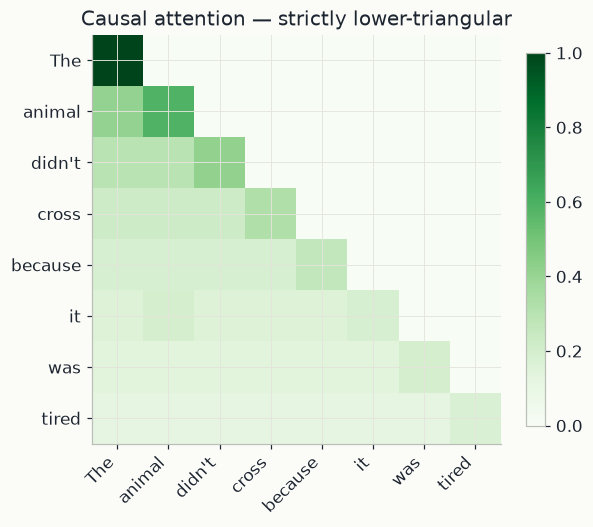

In [7]:
causal_mask = np.tril(np.ones((n, n), dtype=bool))     # True = allowed to attend
_, causal_weights = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(causal_weights, cmap="Greens", vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(tokens)
ax.set_title("Causal attention — strictly lower-triangular")
fig.colorbar(im, ax=ax, shrink=0.8)

upper_triangle_zero = np.allclose(causal_weights[np.triu_indices(n, k=1)], 0)
print(f"weights above the diagonal are exactly zero: {upper_triangle_zero}")

Notice "it" (position 5) can no longer see "was" or "tired" (positions 6-7) — with the
mask on, "it" would have to be resolved from context that comes *before* it, which is
the real constraint an autoregressive model generating left to right has to work
under.

## Exercises

### Exercise 1: Remove the coreference signal
Rebuild `embeddings` as a plain one-hot matrix (skip the "it echoes animal" blend) and
rerun section 6's heatmap. What does the attention pattern look like now, and why?

<details><summary>Solution</summary>

```python
plain_embeddings = np.eye(n)
_, plain_weights = scaled_dot_product_attention(plain_embeddings, plain_embeddings, plain_embeddings)
```
With pure one-hot embeddings every token is equally (dis)similar to every other, so
the softmax is close to uniform — attention has nothing informative to key on because
the embeddings themselves carry no relationship. That's the real lesson: attention's
patterns are only as meaningful as the embeddings (or learned projections) feeding it.
</details>

### Exercise 2: More heads, smaller head dimension
Change `n_heads` to 4 (so each head only gets $d_k = 2$). Do the per-head patterns
look noisier? What's the trade-off multi-head attention is making between number of
heads and dimensionality per head?

<details><summary>Solution</summary>

More heads with the same total `d_model` means each head reasons in a lower-
dimensional subspace, which can make individual head patterns look more erratic —
the trade-off is between having *more distinct relationships* a model can represent
(more heads) versus *more expressive power per relationship* (bigger `d_k` per head).
</details>

## Key takeaways

- Attention scores how well each query matches each key, turns the scores into
  weights with a softmax, and outputs a weighted blend of values — nothing more
  exotic than a differentiable, content-based lookup.
- Multi-head attention runs several smaller attention computations in parallel so
  different heads can specialise in different relationships; concatenating them
  restores the original dimensionality.
- A causal mask blocks attention to future positions, which is what makes
  autoregressive, left-to-right generation well-defined during training.